##### Name : Ansh Yadav
##### Roll no : 36
##### Course : M.S.C(CS) - 8
##### Subject : Machine Learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.datasets import fetch_california_housing
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Q1: Predict House Prices Using California Housing Dataset

In [2]:
# Step 1: Load the dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

In [3]:
# Step 2: Describe dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.

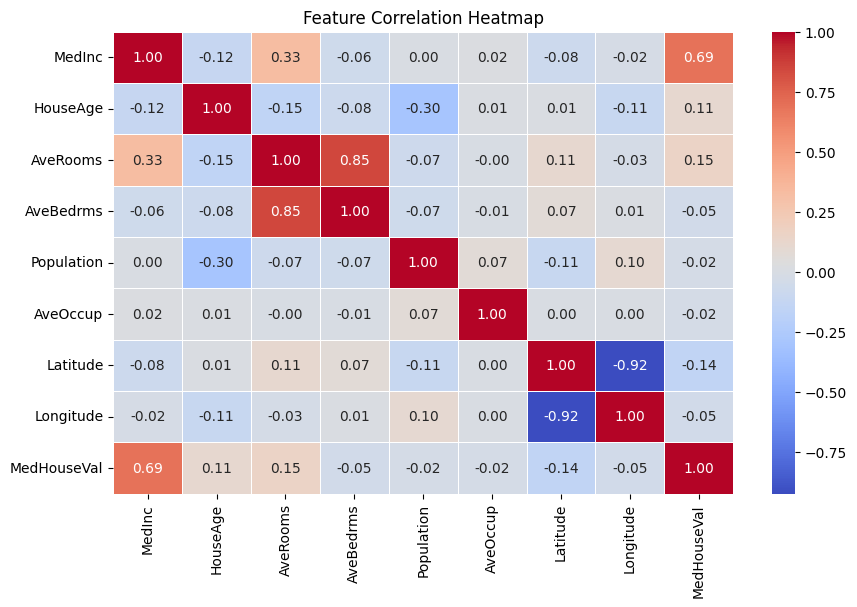

In [4]:
# Step 3: Visualize relationships using heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [5]:
# Step 4: Handle missing values (if any)
df.dropna(inplace=True)

In [6]:
# Step 5: Split data into training and testing sets (80:20)
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Step 6: Normalize/Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# Step 7: Train model and get coefficients
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 0.85438303  0.12254624 -0.29441013  0.33925949 -0.00230772 -0.0408291
 -0.89692888 -0.86984178]
Intercept: 2.0719469373788777


In [9]:
# Step 8: Evaluate model
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 0.5558915986952442
R² Score: 0.575787706032451


In [10]:
# Step 9: Apply Ridge and Lasso Regularization
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

In [11]:
ridge.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [12]:
lasso.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [13]:
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)

print(f'Ridge MSE: {mean_squared_error(y_test, y_pred_ridge)}')
print(f'Lasso MSE: {mean_squared_error(y_test, y_pred_lasso)}')

Ridge MSE: 0.5558548589435971
Lasso MSE: 0.6796290284328825


# Q2: Find the Best Fit Line From Scratch

In [14]:
# Given data
X = np.array([1, 2, 4, 6, 8, 9, 10, 12, 25, 27, 34, 35])
y = np.array([23, 45, 34, 67, 45, 89, 45, 57, 63, 45, 89, 80])

In [15]:
# Step 1: Compute mean of X and y
X_mean = np.mean(X)
y_mean = np.mean(y)

In [16]:
# Step 2: Compute slope (m) and intercept (b) using the least squares method
numerator = sum((X - X_mean) * (y - y_mean))
denominator = sum((X - X_mean) ** 2)
m = numerator / denominator
b = y_mean - m * X_mean

print(f'Best fit line equation: y = {m:.2f}x + {b:.2f}')

Best fit line equation: y = 1.03x + 42.05


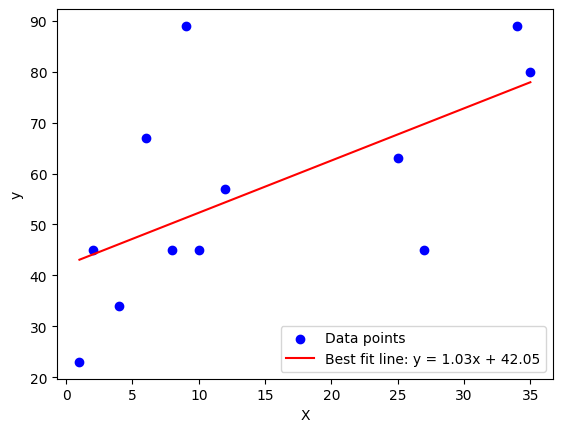

In [18]:
# Step 3: Plot the data and best fit line
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X,  b + m * X, color='red', label=f'Best fit line: y = {m:.2f}x + {b:.2f}')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

# Q3: Predict Titanic Survival Using Titanic Dataset

In [19]:
# Step 1: Load dataset
df = pd.read_csv("./dataset/Titanic-Dataset.csv")

In [20]:
# Step 2: Analyze dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

In [21]:
# Step 3: Handle missing values
imputer = SimpleImputer(strategy="median")
df["Age"] = imputer.fit_transform(df[["Age"]])
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

/tmp/ipykernel_25866/4128807789.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


In [22]:
# Step 4: Encode categorical variables
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,NaN,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,NaN,False,True
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C148,False,False


In [23]:
# Step 5: Select features & target
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked_Q", "Embarked_S"]
X = df[features]
y = df["Survived"]

In [24]:
# Step 6: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Step 7: Train model using Logistic Regression
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [26]:
# Step 8: Make predictions
y_pred = model.predict(X_test)

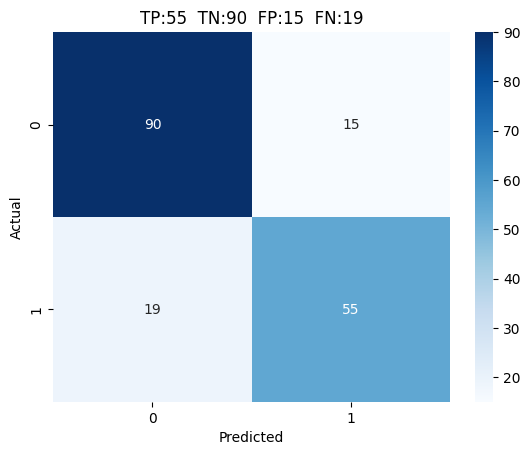

In [27]:
# Step 9: Display confusion matrix heatmap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}")
plt.show()


In [28]:
# Step 10: Calculate metrics
report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Report: \n{report}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Report: 
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Accuracy: 0.8101
Precision: 0.7857
Recall: 0.7432
F1 Score: 0.7639
